# Freshness Classification — Transfer Learning (ResNet50)

## 1. Import Library

In [1]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## 2. Eksplorasi & Visualisasi Dataset

In [2]:
dataset_path = './dataset/'
distribusi_kelas = {}
total_keseluruhan = 0

for nama_kelas in sorted(os.listdir(dataset_path)):
    folder_kelas = os.path.join(dataset_path, nama_kelas)
    if os.path.isdir(folder_kelas):
        jumlah_gambar = len([f for f in os.listdir(folder_kelas) if not f.startswith('.')])
        distribusi_kelas[nama_kelas] = jumlah_gambar
        total_keseluruhan += jumlah_gambar

print(f"Total kelas: {len(distribusi_kelas)}")
print(f"Total keseluruhan gambar: {total_keseluruhan}")
print(f"Rata-rata gambar per kelas: {total_keseluruhan // len(distribusi_kelas)}")
print(f"Kelas terkecil: {min(distribusi_kelas.values())} gambar")
print(f"Kelas terbesar: {max(distribusi_kelas.values())} gambar")

Total kelas: 44
Total keseluruhan gambar: 53616
Rata-rata gambar per kelas: 1218
Kelas terkecil: 51 gambar
Kelas terbesar: 6140 gambar


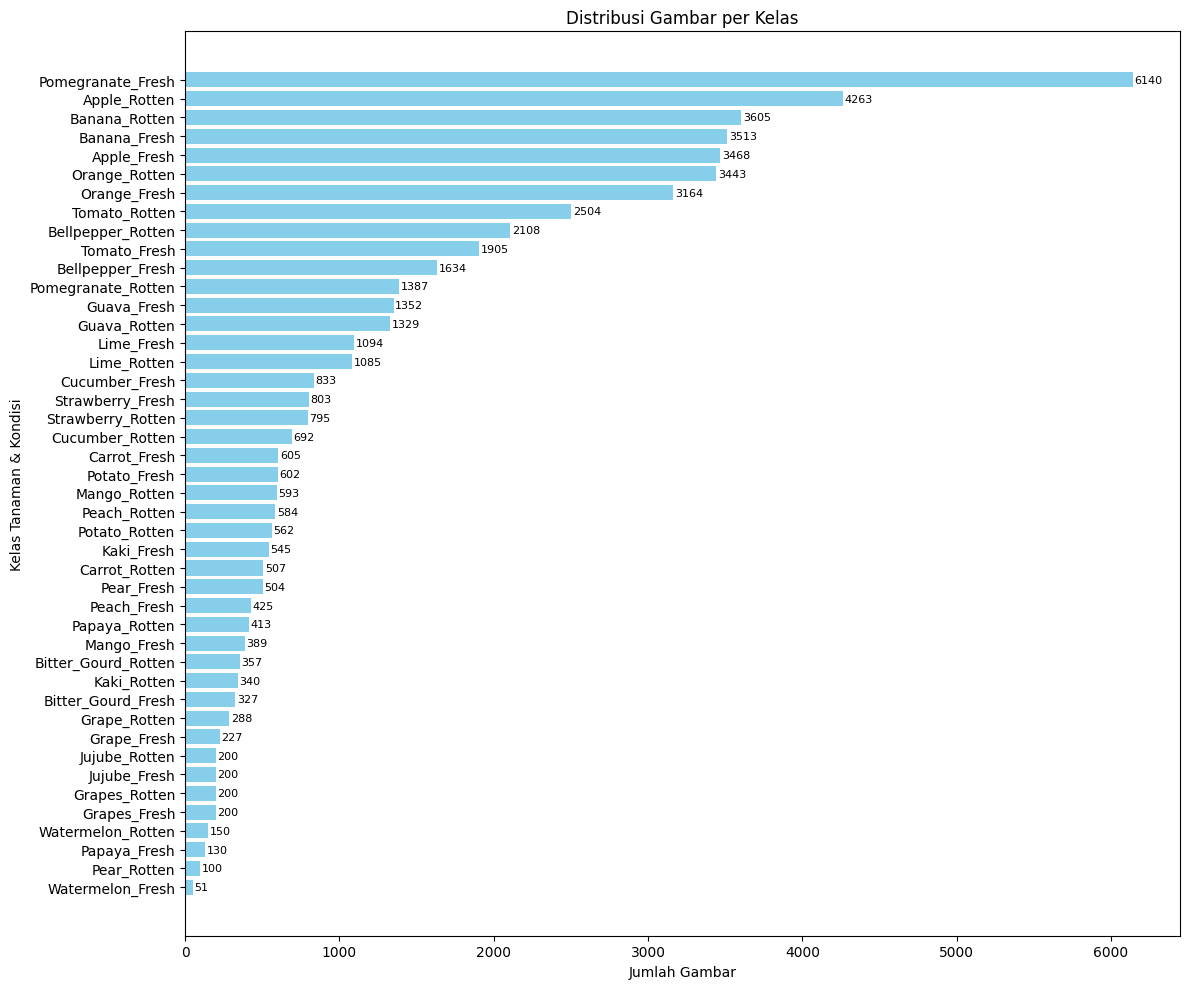

In [3]:
# Visualisasi distribusi kelas
kelas_terurut = sorted(distribusi_kelas.items(), key=lambda x: x[1], reverse=False)
nama_kelas = [item[0] for item in kelas_terurut]
jumlah = [item[1] for item in kelas_terurut]

plt.figure(figsize=(12, 10))
bars = plt.barh(nama_kelas, jumlah, color='skyblue')

for index, value in enumerate(jumlah):
    plt.text(value + 10, index, str(value), va='center', fontsize=8)

plt.xlabel('Jumlah Gambar')
plt.ylabel('Kelas Tanaman & Kondisi')
plt.title('Distribusi Gambar per Kelas')
plt.tight_layout()
plt.show()

## 3. Setup

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 4. Data Preprocessing & Splitting

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
dataset_for_train = datasets.ImageFolder(root=dataset_path, transform=train_transform)
dataset_for_val   = datasets.ImageFolder(root=dataset_path, transform=eval_transform)
dataset_for_test  = datasets.ImageFolder(root=dataset_path, transform=eval_transform)

# Jumlah kelas diambil secara dinamis
jumlah_kelas = len(dataset_for_train.classes)
class_names = dataset_for_train.classes
targets = dataset_for_train.targets

print(f"Jumlah kelas: {jumlah_kelas}")
print(f"Nama kelas: {class_names}")

Jumlah kelas: 44
Nama kelas: ['Apple_Fresh', 'Apple_Rotten', 'Banana_Fresh', 'Banana_Rotten', 'Bellpepper_Fresh', 'Bellpepper_Rotten', 'Bitter_Gourd_Fresh', 'Bitter_Gourd_Rotten', 'Carrot_Fresh', 'Carrot_Rotten', 'Cucumber_Fresh', 'Cucumber_Rotten', 'Grape_Fresh', 'Grape_Rotten', 'Grapes_Fresh', 'Grapes_Rotten', 'Guava_Fresh', 'Guava_Rotten', 'Jujube_Fresh', 'Jujube_Rotten', 'Kaki_Fresh', 'Kaki_Rotten', 'Lime_Fresh', 'Lime_Rotten', 'Mango_Fresh', 'Mango_Rotten', 'Orange_Fresh', 'Orange_Rotten', 'Papaya_Fresh', 'Papaya_Rotten', 'Peach_Fresh', 'Peach_Rotten', 'Pear_Fresh', 'Pear_Rotten', 'Pomegranate_Fresh', 'Pomegranate_Rotten', 'Potato_Fresh', 'Potato_Rotten', 'Strawberry_Fresh', 'Strawberry_Rotten', 'Tomato_Fresh', 'Tomato_Rotten', 'Watermelon_Fresh', 'Watermelon_Rotten']


In [7]:
train_idx, temp_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.3,
    shuffle=True,
    stratify=targets,
    random_state=42
)

temp_targets = np.array(targets)[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    shuffle=True,
    stratify=temp_targets,
    random_state=42
)

train_dataset = Subset(dataset_for_train, train_idx)
val_dataset   = Subset(dataset_for_val, val_idx)
test_dataset  = Subset(dataset_for_test, test_idx)

print(f"Jumlah data Training   : {len(train_dataset)} ({len(train_dataset)/len(targets)*100:.1f}%)")
print(f"Jumlah data Validation : {len(val_dataset)} ({len(val_dataset)/len(targets)*100:.1f}%)")
print(f"Jumlah data Testing    : {len(test_dataset)} ({len(test_dataset)/len(targets)*100:.1f}%)")
print(f"Total                  : {len(train_dataset) + len(val_dataset) + len(test_dataset)}")

Jumlah data Training   : 37531 (70.0%)
Jumlah data Validation : 8042 (15.0%)
Jumlah data Testing    : 8043 (15.0%)
Total                  : 53616


In [8]:
batch_size = 32
num_workers = 4 if device.type == 'cuda' else 0

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True
)

print(f"Batch size: {batch_size}")
print(f"Num workers: {num_workers}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 32
Num workers: 4
Train batches: 1173
Val batches: 252
Test batches: 252


## 5. Arsitektur Model — ResNet50 Transfer Learning

In [9]:
# Load ResNet50 pretrained
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze semua layer backbone
for param in model.parameters():
    param.requires_grad = False

# Ganti classifier head (FC layer terakhir)
# Kita ganti dengan custom head yang mirip baseline (ada Dropout + ReLU)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, jumlah_kelas)
)

model = model.to(device)

# Hitung parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Arsitektur: ResNet50 (ImageNet pretrained)")
print(f"Total parameter     : {total_params:,}")
print(f"Trainable parameter : {trainable_params:,}  (classifier head)")
print(f"Frozen parameter    : {frozen_params:,}  (backbone)")
print(f"\nClassifier head yang akan di-train:")
print(model.fc)

Arsitektur: ResNet50 (ImageNet pretrained)
Total parameter     : 24,579,692
Trainable parameter : 1,071,660  (classifier head)
Frozen parameter    : 23,508,032  (backbone)

Classifier head yang akan di-train:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=44, bias=True)
)


## 6. Loss Function, Optimizer, & Scheduler

In [10]:
# Focal Loss — SAMA dengan baseline
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [11]:
# Class weights untuk menangani imbalance
class_counts = np.bincount(targets)
class_weights = len(targets) / (jumlah_kelas * class_counts)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Loss function
criterion = FocalLoss(weight=weights_tensor, gamma=2.0)

# Optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001, weight_decay=1e-4
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

## 7. Training Fase 1: Feature Extraction (Frozen Backbone)

In [13]:
# Early Stopping class
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"  >> EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [14]:
# FASE 1: Feature Extraction — Frozen Backbone, Train Head Only
fase1_epochs = 20
early_stopping = EarlyStopping(patience=5, min_delta=0.001)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],
    'lr': [], 'fase': []
}

best_val_acc = 0.0
best_model_state = None
start_time = time.time()

for epoch in range(fase1_epochs):
    epoch_start = time.time()
    
    # FASE TRAINING
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train * 100
    
    # FASE VALIDATION
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val * 100
    
    current_lr = optimizer.param_groups[0]['lr']
    
    # Simpan history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    history['fase'].append(1)
    
    # Simpan best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        save_marker = ' << BEST'
    else:
        save_marker = ''
    
    epoch_time = time.time() - epoch_start
    
    print(f"Fase1 Epoch [{epoch+1:2d}/{fase1_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {current_lr:.6f} | Time: {epoch_time:.1f}s{save_marker}")
    
    scheduler.step(val_loss)
    
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"\n>> Early stopping triggered pada Fase 1, epoch {epoch+1}!")
        break

fase1_time = time.time() - start_time
print(f"\nFase 1 selesai dalam {fase1_time:.1f}s ({fase1_time/60:.1f} min)")
print(f"Best Val Accuracy (Fase 1): {best_val_acc:.2f}%")

Fase1 Epoch [ 1/20] | Train Loss: 0.5911 | Train Acc: 67.88% | Val Loss: 0.1180 | Val Acc: 88.85% | LR: 0.001000 | Time: 260.8s << BEST
Fase1 Epoch [ 2/20] | Train Loss: 0.2380 | Train Acc: 78.11% | Val Loss: 0.0958 | Val Acc: 89.38% | LR: 0.001000 | Time: 156.5s << BEST
Fase1 Epoch [ 3/20] | Train Loss: 0.2098 | Train Acc: 80.04% | Val Loss: 0.0969 | Val Acc: 91.10% | LR: 0.001000 | Time: 150.0s << BEST
  >> EarlyStopping counter: 1/5
Fase1 Epoch [ 4/20] | Train Loss: 0.1952 | Train Acc: 80.74% | Val Loss: 0.0930 | Val Acc: 88.93% | LR: 0.001000 | Time: 150.9s
Fase1 Epoch [ 5/20] | Train Loss: 0.1974 | Train Acc: 81.35% | Val Loss: 0.0680 | Val Acc: 91.15% | LR: 0.001000 | Time: 257.5s << BEST
Fase1 Epoch [ 6/20] | Train Loss: 0.1815 | Train Acc: 81.86% | Val Loss: 0.0725 | Val Acc: 90.38% | LR: 0.001000 | Time: 158.4s
  >> EarlyStopping counter: 1/5
Fase1 Epoch [ 7/20] | Train Loss: 0.1753 | Train Acc: 82.11% | Val Loss: 0.0884 | Val Acc: 91.71% | LR: 0.001000 | Time: 151.7s << BEST


## 8. Training Fase 2: Fine-Tuning (Unfreeze Layer Terakhir)

In [15]:
# Unfreeze layer4 (blok residual terakhir) untuk fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True

# Differential Learning Rate:
# - Backbone layer4: LR kecil (1e-4) agar tidak merusak pretrained features
# - Classifier head: LR lebih besar (5e-4) agar adaptasi lebih cepat
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 5e-4}
], weight_decay=1e-4)

# Reset scheduler dan early stopping untuk fase 2
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)
early_stopping = EarlyStopping(patience=5, min_delta=0.001)

# Hitung trainable params setelah unfreeze
trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameter setelah unfreeze layer4: {trainable_now:,}")
print(f"Differential LR: layer4=1e-4, head=5e-4")

Trainable parameter setelah unfreeze layer4: 16,036,396
Differential LR: layer4=1e-4, head=5e-4


In [16]:
# FASE 2: Fine-Tuning — Unfreeze layer4 + classifier head
fase2_epochs = 30
fase2_start = time.time()

for epoch in range(fase2_epochs):
    epoch_start = time.time()
    
    # FASE TRAINING
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train * 100
    
    # FASE VALIDATION
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val * 100
    
    # Ambil LR dari grup pertama (backbone)
    current_lr_backbone = optimizer.param_groups[0]['lr']
    current_lr_head = optimizer.param_groups[1]['lr']
    
    # Simpan history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr_head)
    history['fase'].append(2)
    
    # Simpan best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        save_marker = ' << BEST'
    else:
        save_marker = ''
    
    epoch_time = time.time() - epoch_start
    
    print(f"Fase2 Epoch [{epoch+1:2d}/{fase2_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR(bb): {current_lr_backbone:.6f} | LR(head): {current_lr_head:.6f} | "
          f"Time: {epoch_time:.1f}s{save_marker}")
    
    scheduler.step(val_loss)
    
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"\n>> Early stopping triggered pada Fase 2, epoch {epoch+1}!")
        break

total_time = time.time() - start_time
print(f"\nTotal training selesai dalam {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"Best Validation Accuracy (overall): {best_val_acc:.2f}%")

Fase2 Epoch [ 1/30] | Train Loss: 0.0984 | Train Acc: 89.01% | Val Loss: 0.0417 | Val Acc: 95.76% | LR(bb): 0.000100 | LR(head): 0.000500 | Time: 197.2s << BEST
Fase2 Epoch [ 2/30] | Train Loss: 0.0766 | Train Acc: 90.92% | Val Loss: 0.0348 | Val Acc: 96.26% | LR(bb): 0.000100 | LR(head): 0.000500 | Time: 251.5s << BEST
Fase2 Epoch [ 3/30] | Train Loss: 0.0502 | Train Acc: 92.62% | Val Loss: 0.0329 | Val Acc: 96.67% | LR(bb): 0.000100 | LR(head): 0.000500 | Time: 168.5s << BEST
Fase2 Epoch [ 4/30] | Train Loss: 0.0509 | Train Acc: 93.04% | Val Loss: 0.0301 | Val Acc: 96.97% | LR(bb): 0.000100 | LR(head): 0.000500 | Time: 170.1s << BEST
Fase2 Epoch [ 5/30] | Train Loss: 0.0433 | Train Acc: 93.46% | Val Loss: 0.0331 | Val Acc: 96.48% | LR(bb): 0.000100 | LR(head): 0.000500 | Time: 167.6s
  >> EarlyStopping counter: 1/5
Fase2 Epoch [ 6/30] | Train Loss: 0.0369 | Train Acc: 94.08% | Val Loss: 0.0353 | Val Acc: 97.05% | LR(bb): 0.000100 | LR(head): 0.000500 | Time: 167.3s << BEST
  >> Early

In [ ]:
# # Simpan best model
# torch.save(best_model_state, 'model_freshness_resnet50.pth')
# print("Best model berhasil disimpan ke 'model_freshness_resnet50.pth'")

# Load best model untuk evaluasi
model.load_state_dict(best_model_state)
print("Best model berhasil di-load untuk evaluasi.")

Best model berhasil disimpan ke 'model_freshness_resnet50.pth'
Best model berhasil di-load untuk evaluasi.


## 9. Visualisasi Training History

In [12]:
import torchvision.models as models

model = model.to(device)
model.load_state_dict(torch.load('model_freshness_resnet50.pth', map_location=device))
model.eval()
print("ResNet50 berhasil di-load.")

ResNet50 berhasil di-load.


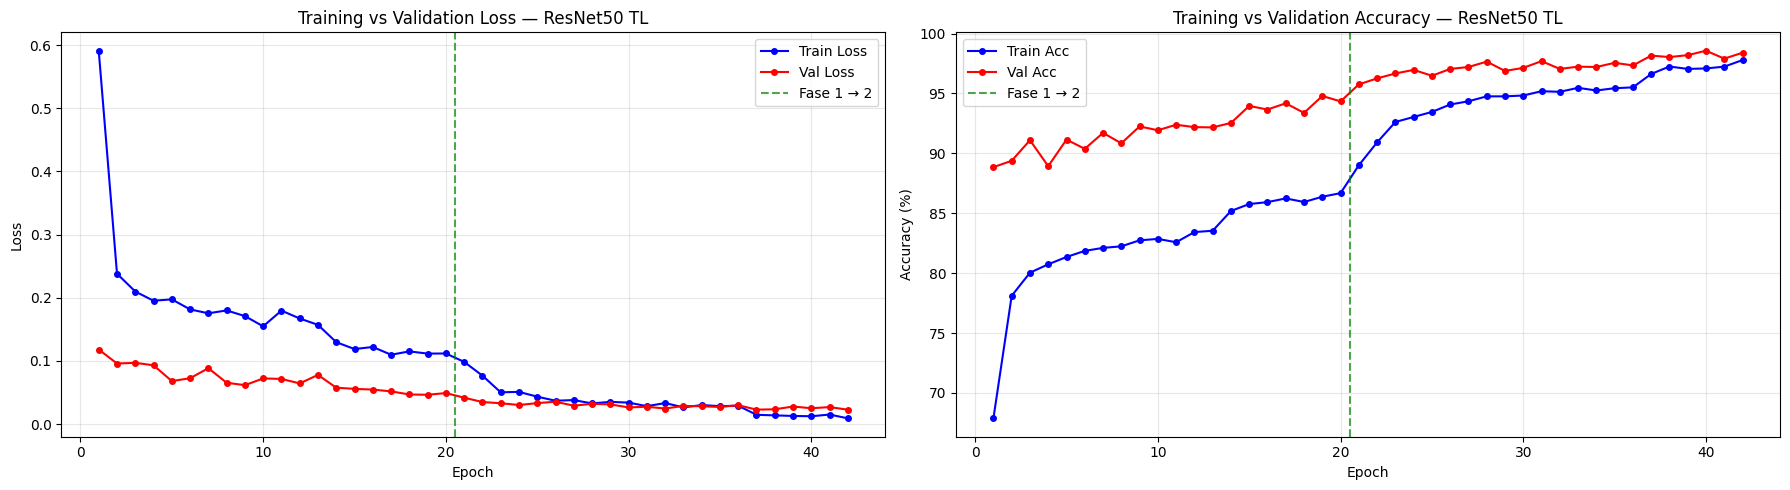

Plot disimpan ke 'training_history_resnet50_tl.png'


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
epoch_range = range(1, len(history['train_loss']) + 1)

# Tentukan batas fase 1 dan fase 2
fase1_end = sum(1 for f in history['fase'] if f == 1)

# Plot 1: Loss
axes[0].plot(epoch_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epoch_range, history['val_loss'], 'r-o', markersize=4, label='Val Loss')
axes[0].axvline(x=fase1_end + 0.5, color='green', linestyle='--', alpha=0.7, label='Fase 1 → 2')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss — ResNet50 TL')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[1].plot(epoch_range, history['train_acc'], 'b-o', markersize=4, label='Train Acc')
axes[1].plot(epoch_range, history['val_acc'], 'r-o', markersize=4, label='Val Acc')
axes[1].axvline(x=fase1_end + 0.5, color='green', linestyle='--', alpha=0.7, label='Fase 1 → 2')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training vs Validation Accuracy — ResNet50 TL')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_resnet50_tl.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan ke 'training_history_resnet50_tl.png'")

## 10. Evaluasi pada Test Set

In [14]:
# Evaluasi pada TEST set (bukan val set) — SAMA dengan baseline
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Test accuracy
test_acc = (all_preds == all_labels).sum() / len(all_labels) * 100
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 98.60%


In [15]:
# Classification Report — SAMA format dengan baseline
print("CLASSIFICATION REPORT — ResNet50 Transfer Learning")
report = classification_report(
    all_labels, all_preds, target_names=class_names, zero_division=0
)
print(report)

CLASSIFICATION REPORT — ResNet50 Transfer Learning
                     precision    recall  f1-score   support

        Apple_Fresh       0.98      0.99      0.99       520
       Apple_Rotten       0.99      0.98      0.99       640
       Banana_Fresh       1.00      0.99      1.00       527
      Banana_Rotten       0.99      1.00      0.99       541
   Bellpepper_Fresh       0.97      1.00      0.99       245
  Bellpepper_Rotten       0.98      0.97      0.97       316
 Bitter_Gourd_Fresh       1.00      1.00      1.00        49
Bitter_Gourd_Rotten       1.00      1.00      1.00        53
       Carrot_Fresh       0.96      0.96      0.96        91
      Carrot_Rotten       0.92      0.91      0.91        76
     Cucumber_Fresh       0.98      1.00      0.99       125
    Cucumber_Rotten       0.99      0.96      0.98       104
        Grape_Fresh       1.00      1.00      1.00        34
       Grape_Rotten       0.98      1.00      0.99        43
       Grapes_Fresh       1.00   

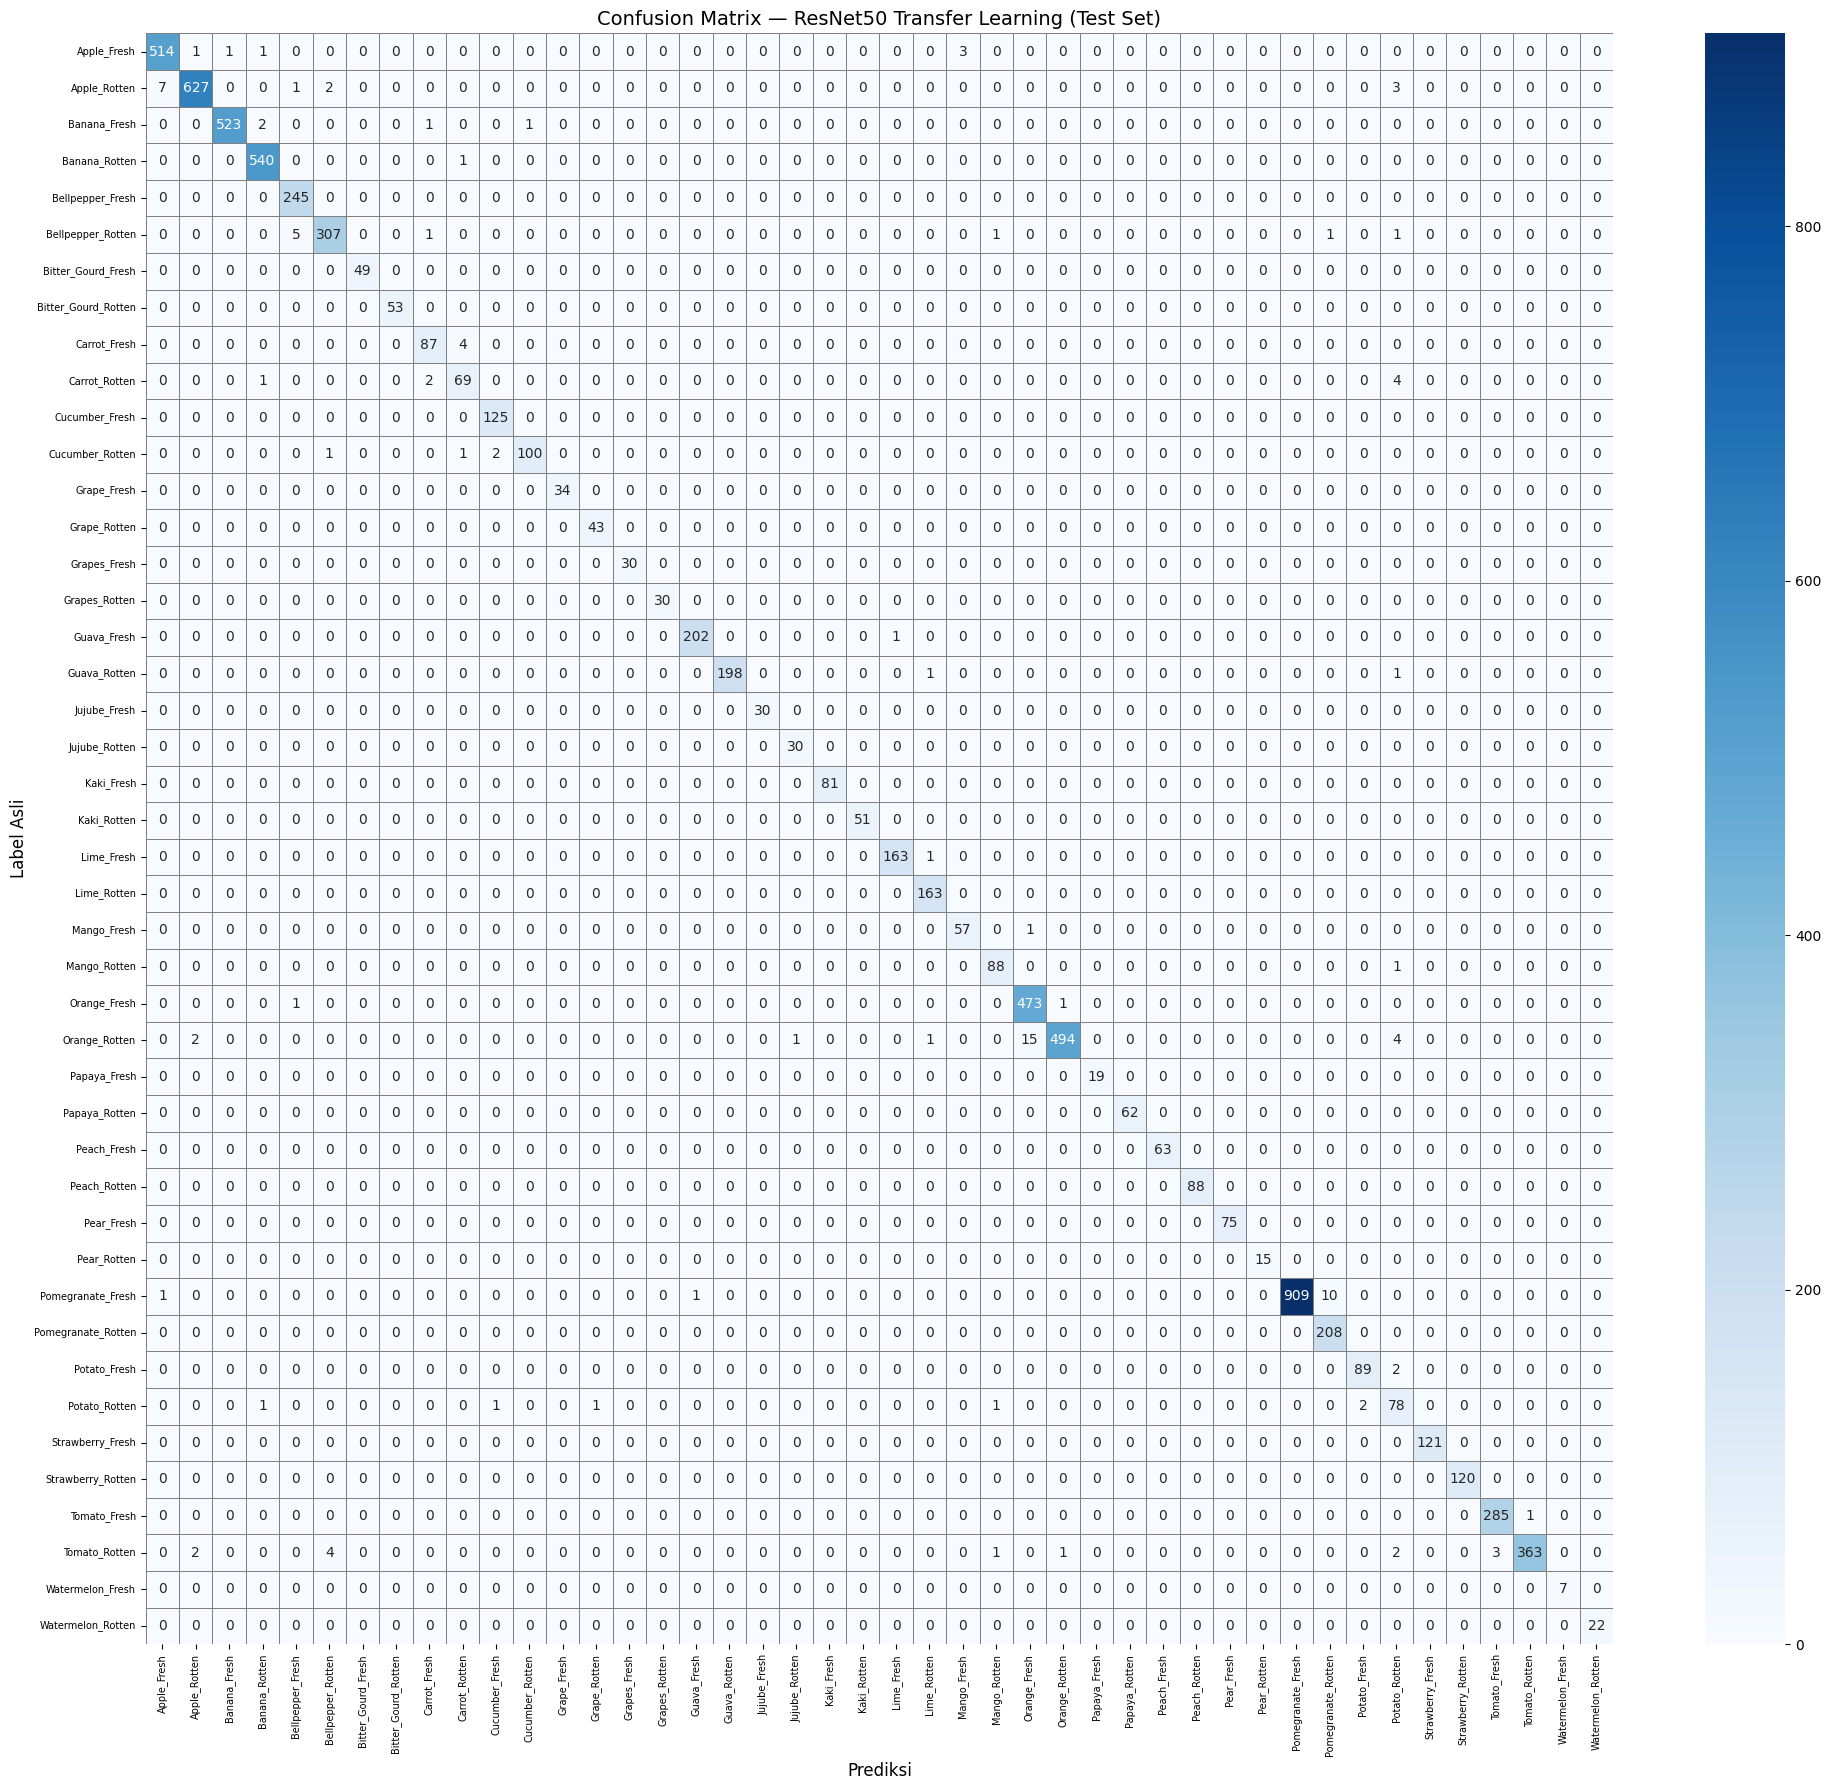

Confusion matrix disimpan ke 'confusion_matrix_resnet50_tl.png'


In [23]:
# Confusion Matrix — SAMA format dengan baseline
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, linecolor='gray'
)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Label Asli', fontsize=12)
plt.title('Confusion Matrix — ResNet50 Transfer Learning (Test Set)', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix_resnet50_tl.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix disimpan ke 'confusion_matrix_resnet50_tl.png'")

## 11. Error Analysis

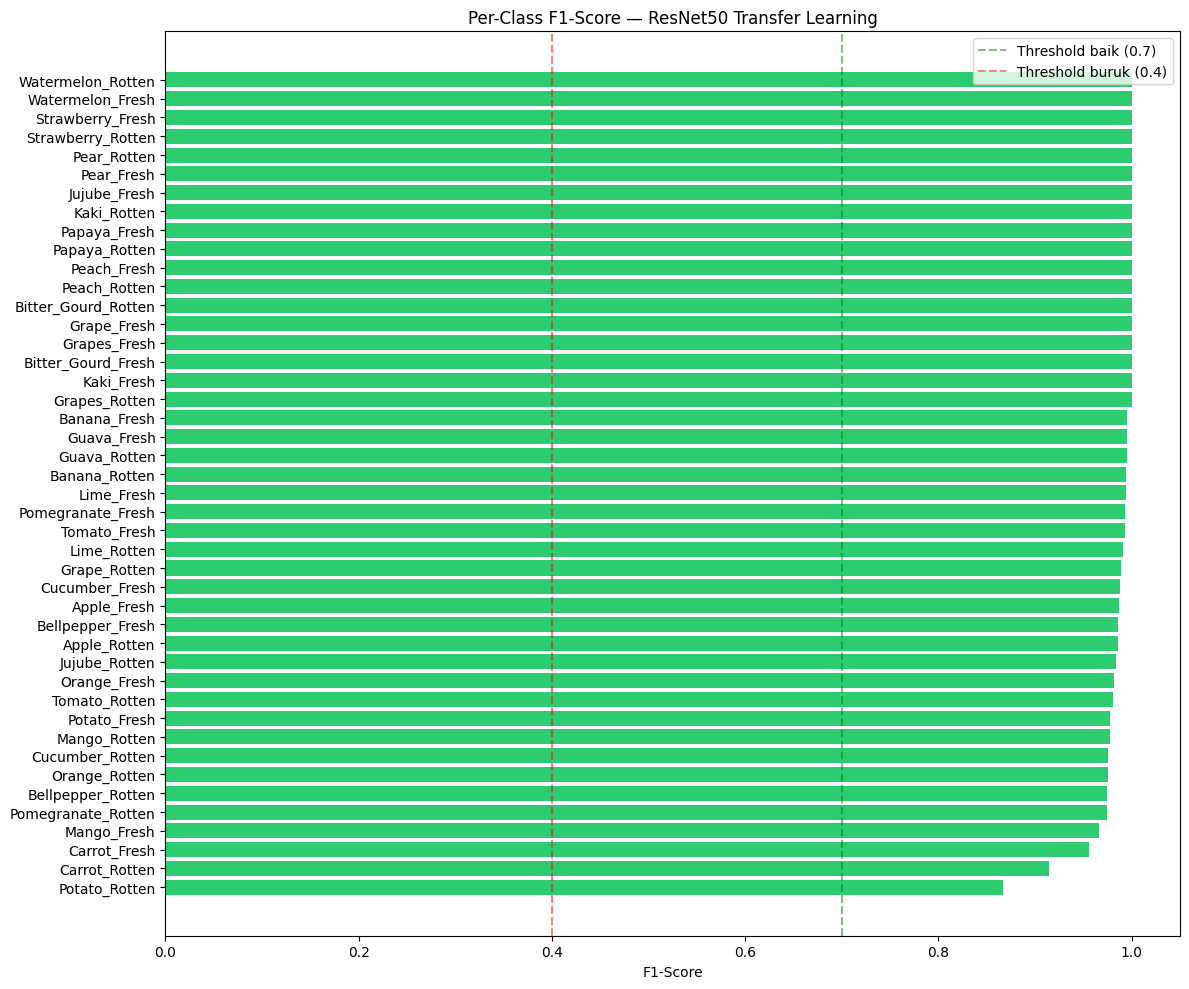

In [25]:
report_dict = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    output_dict=True
)

# Buat dict class_name -> f1-score
class_f1 = {name: report_dict[name]['f1-score'] for name in class_names}

# Visualisasi: Per-class F1-score — SAMA format dengan baseline
f1_scores = [class_f1[name] for name in class_names]
sorted_idx = np.argsort(f1_scores)
sorted_names = [class_names[i] for i in sorted_idx]
sorted_f1 = [f1_scores[i] for i in sorted_idx]

colors = ['#e74c3c' if f1 < 0.4 else '#f39c12' if f1 < 0.7 else '#2ecc71' for f1 in sorted_f1]

plt.figure(figsize=(12, 10))
plt.barh(sorted_names, sorted_f1, color=colors)
plt.xlabel('F1-Score')
plt.title('Per-Class F1-Score — ResNet50 Transfer Learning')
plt.axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='Threshold baik (0.7)')
plt.axvline(x=0.4, color='red', linestyle='--', alpha=0.5, label='Threshold buruk (0.4)')
plt.legend()
plt.tight_layout()
plt.savefig('per_class_f1_resnet50_tl.png', dpi=150, bbox_inches='tight')
plt.show()

# Test

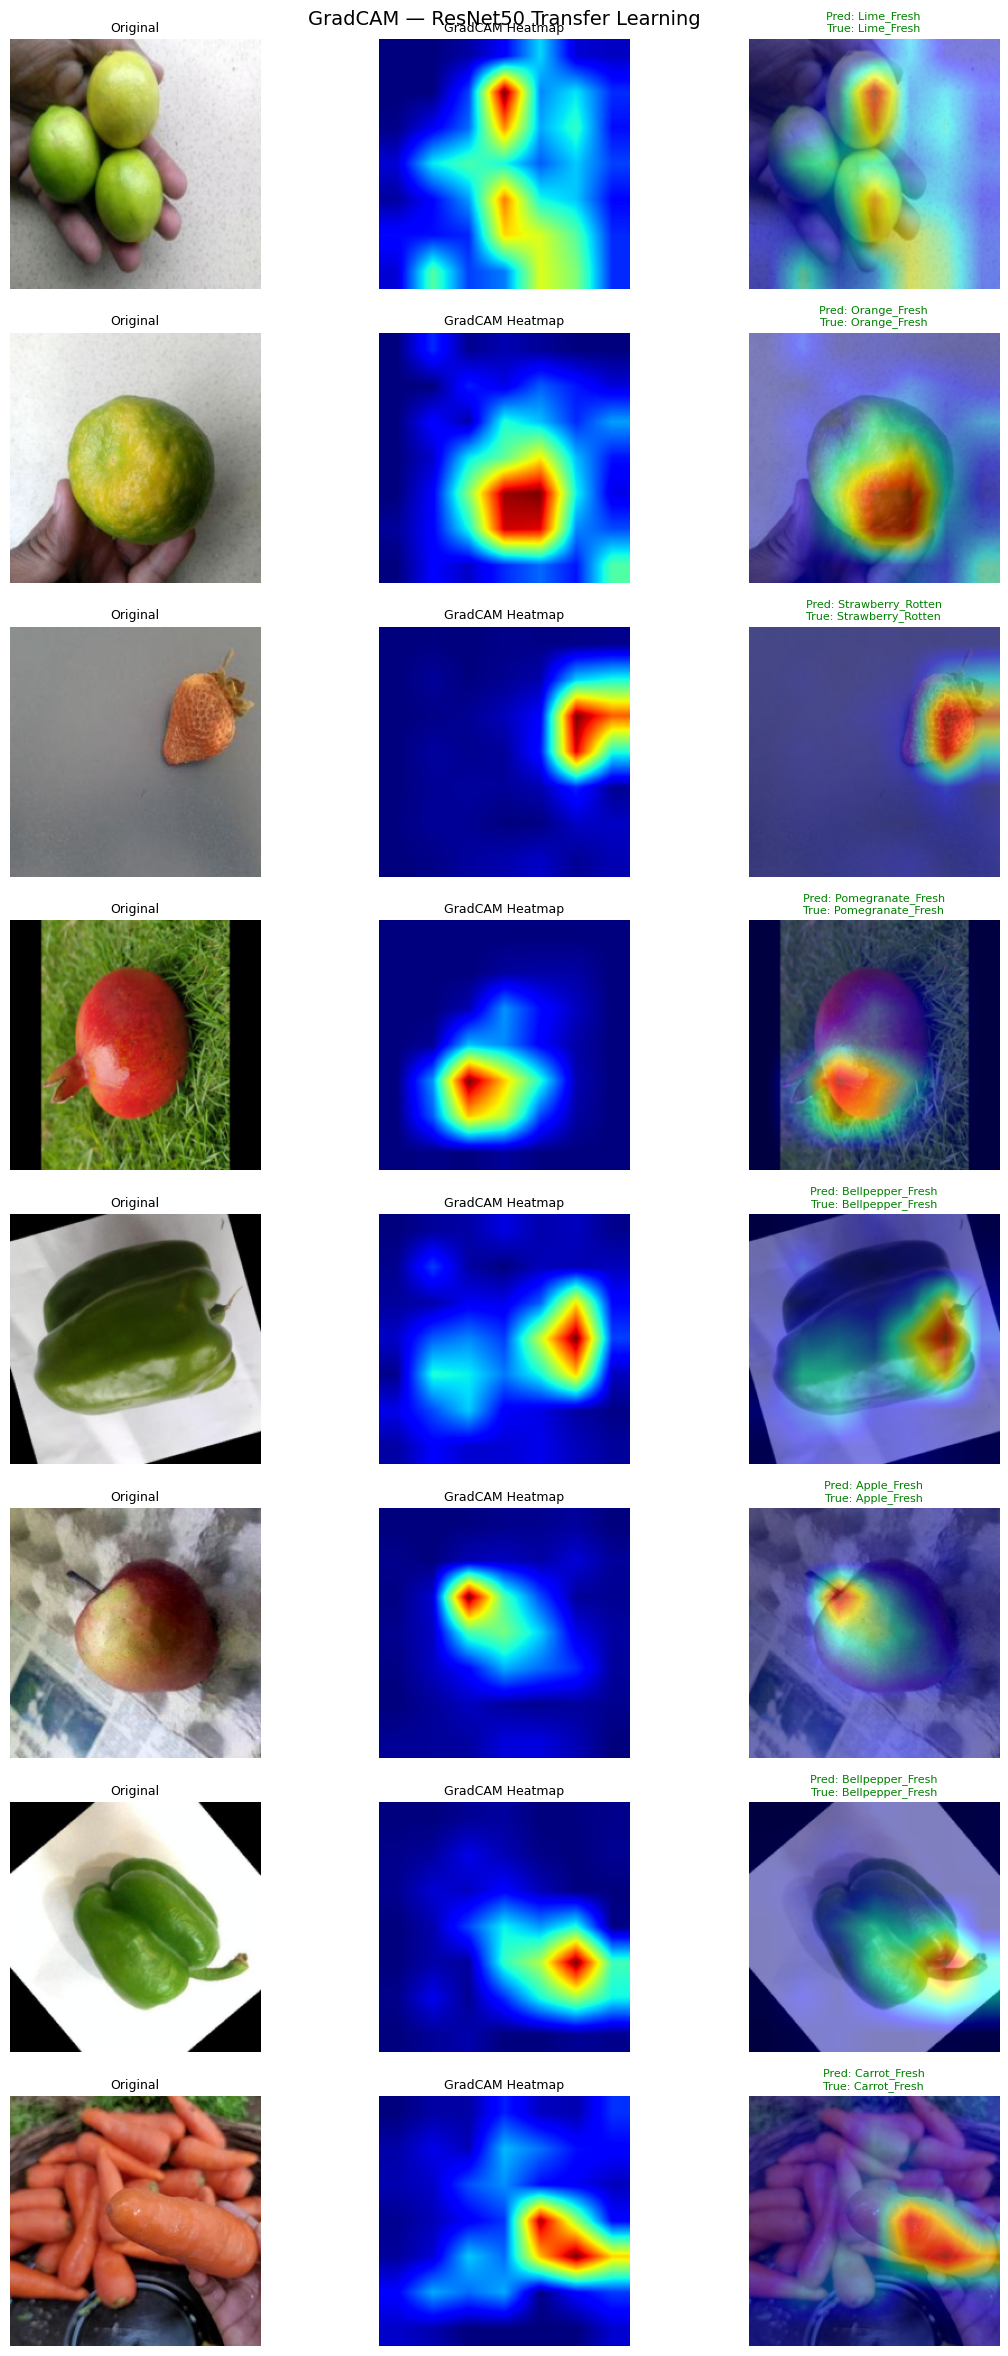

In [18]:
import cv2

try:
    hook.remove()
except:
    pass

model.eval()

gradients = []
activations = []

def save_gradient(grad):
    gradients.append(grad)

def forward_hook(module, input, output):
    output = output.requires_grad_(True)  # paksa requires_grad
    activations.append(output)
    output.register_hook(save_gradient)

hook = model.layer4.register_forward_hook(forward_hook)

def generate_gradcam_resnet(img_tensor, class_idx=None):
    gradients.clear()
    activations.clear()
    
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    with torch.enable_grad():
        output = model(img_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        model.zero_grad()
        output[0, class_idx].backward()
    
    grad = gradients[0].squeeze(0)
    act  = activations[0].squeeze(0).detach()
    weights = grad.mean(dim=(1, 2))
    
    cam = torch.zeros(act.shape[1:])
    for i, w in enumerate(weights):
        cam += w.item() * act[i].cpu()
    
    cam = F.relu(cam).numpy()
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, class_idx

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.cpu().numpy().transpose(1, 2, 0)
    img  = img * std + mean
    return np.clip(img, 0, 1)

n_samples = 8
sample_indices = np.random.choice(len(test_dataset), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 3))
fig.suptitle('GradCAM — ResNet50 Transfer Learning', fontsize=14)

for i, idx in enumerate(sample_indices):
    img_tensor, true_label = test_dataset[idx]
    
    cam, pred_idx = generate_gradcam_resnet(img_tensor)
    img_np = denormalize(img_tensor)
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * img_np + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)
    
    pred_label = class_names[pred_idx]
    true_label_name = class_names[true_label]
    color = 'green' if pred_idx == true_label else 'red'
    
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title('Original', fontsize=9)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cam, cmap='jet')
    axes[i, 1].set_title('GradCAM Heatmap', fontsize=9)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title(f'Pred: {pred_label}\nTrue: {true_label_name}', fontsize=8, color=color)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_resnet50.png', dpi=150, bbox_inches='tight')
plt.show()

hook.remove()